# Content Quality & Engagement Prediction — Part 3a
### Modeling: Train/Val/Test Split, Baselines, Model Comparison & Selection

This notebook continues from **01_data_profiling** (cleaning) and **02_eda_feature_engineering** (EDA, target definition, feature engineering), using their final output `data/modeling_dataset_v2.csv`. Here we:

1. Build a leakage-safe, chronological train/validation/test split
2. Train and compare four classifiers: Logistic Regression, Random Forest, Gradient Boosting (HistGradientBoosting), and XGBoost
3. Evaluate with imbalance-aware metrics (PR-AUC, F1, recall — not accuracy)
4. Select a best model on validation and score it once, on the untouched test set

**Target:** `is_high_engagement` (top-quartile `engagement_score`, defined and justified in Part 2). Interpretation and error analysis continue in **04_model_interpretation.ipynb**. Models are trained and compared here — no model is deployed, and none is claimed production-ready without evidence.

## 0. Setup & Load Part 2 Output

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
    average_precision_score, confusion_matrix, f1_score, precision_score,
    recall_score, roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FIG_DIR = "../outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [2]:
df = pd.read_csv("../data/modeling_dataset_v2.csv", parse_dates=["created_date"])
df = df.sort_values(["created_date", "question_id"]).reset_index(drop=True)
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)

Loaded: 37,719 rows x 31 columns


,question_id,user_id,created_date,account_age_bucket,asker_account_age_at_question_days,asker_country,asker_device_type,asker_prior_quality_rate,asker_prior_questions_count,created_dow,created_is_weekend,log_word_count,topic,topic_prior_count,topic_prior_quality_rate,variant,word_count,word_count_bucket,word_count_z_within_topic,num_views,num_answers,num_upvotes,upvote_rate,answer_rate,engagement_score,is_high_engagement,unique_answer_actors,unique_ask_actors,unique_upvote_actors,unique_view_actors,got_quality_answer
0,1,25,2026-06-01,veteran (1yr+),312,de,mobile,NaN,0,Monday,False,4.262680,sports,0,0.696599,control,70,long,1.206664,33,1,3,0.090909,0.030303,0.244509,0,0,1,1,5,1
1,2,32,2026-06-01,veteran (1yr+),767,us,mobile,NaN,0,Monday,False,3.891820,technology,0,0.696599,control,48,medium,0.282395,23,0,1,0.043478,0.000000,0.134494,0,0,1,1,2,0
2,3,61,2026-06-01,veteran (1yr+),632,us,desktop,NaN,0,Monday,False,3.496508,education,0,0.696599,treatment,32,medium,-0.354128,20,3,14,0.700000,0.150000,0.297025,1,0,1,1,5,1


## 1. Recap: Target and Leakage-Safe Feature Set

**Target:** `is_high_engagement` — top-quartile of `engagement_score`
(justified in Part 2; class balance ~75% / 25%).

**Features used** (all established as leakage-safe in Parts 1–2 — none is an
outcome that occurs concurrently with or after engagement is measured):

In [3]:
NUMERIC_FEATURES = [
    "asker_prior_questions_count", "asker_prior_quality_rate",
    "topic_prior_count", "topic_prior_quality_rate",
    "word_count", "log_word_count", "word_count_z_within_topic",
    "asker_account_age_at_question_days",
]
CATEGORICAL_FEATURES = [
    "asker_country", "asker_device_type", "account_age_bucket", "topic",
    "created_dow", "created_is_weekend", "variant",
]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "is_high_engagement"

# Explicitly excluded (outcome / leakage columns - see Parts 1-2):
#   num_views, num_answers, num_upvotes, upvote_rate, answer_rate,
#   engagement_score (IS the target's source), unique_*_actors,
#   got_quality_answer (a concurrent outcome, not a prior signal),
#   word_count_bucket (redundant with word_count/log_word_count; dropped
#   here to avoid encoding the same information twice across a numeric and
#   a categorical column, which would double-count it for tree models and
#   add uninformative multicollinearity for the linear model)

print(f"Numeric features ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"Categorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"Target: {TARGET}")

Numeric features (8): ['asker_prior_questions_count', 'asker_prior_quality_rate', 'topic_prior_count', 'topic_prior_quality_rate', 'word_count', 'log_word_count', 'word_count_z_within_topic', 'asker_account_age_at_question_days']
Categorical features (7): ['asker_country', 'asker_device_type', 'account_age_bucket', 'topic', 'created_dow', 'created_is_weekend', 'variant']
Target: is_high_engagement


## 2. Train / Validation / Test Split

**Strategy: chronological split, not random.** The platform will deploy this
model to score *new, future* questions — a random split would let the model
implicitly "see the future" through engineered features that were computed
using dataset-wide statistics (e.g. `word_count_z_within_topic` uses topic
mean/std over the whole dataset). A time-based split is the realistic
simulation of production use: **train on the past, validate and test on
data the model has never seen chronologically.**

Split: first 70% of dates → train, next 15% → validation (model selection /
hyperparameter choices), final 15% → test (final, untouched evaluation).

In [4]:
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

for name, part in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"{name:<11}: {len(part):>6,} rows | {part.created_date.min().date()} -> "
          f"{part.created_date.max().date()} | positive rate = {part[TARGET].mean():.1%}")

Train      : 26,403 rows | 2026-06-01 -> 2026-07-12 | positive rate = 25.0%
Validation :  5,658 rows | 2026-07-12 -> 2026-07-21 | positive rate = 24.6%
Test       :  5,658 rows | 2026-07-21 -> 2026-07-30 | positive rate = 25.5%


Class balance is preserved reasonably well across all three splits (24.6%–
25.5% positive) purely as a byproduct of the target being flat over time
(confirmed in Part 2) — no manual stratification was needed on top of the
chronological split.

In [5]:
X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_val, y_val = val_df[FEATURES], val_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

print(f"asker_prior_quality_rate missing: train={X_train.asker_prior_quality_rate.isnull().mean():.1%}, "
      f"val={X_val.asker_prior_quality_rate.isnull().mean():.1%}, test={X_test.asker_prior_quality_rate.isnull().mean():.1%}")
print("(missing = user's first-ever question, no prior history yet - a real, informative null; median-imputed below.)")

asker_prior_quality_rate missing: train=36.1%, val=9.7%, test=6.8%
(missing = user's first-ever question, no prior history yet - a real, informative null; median-imputed below.)


## 3. Preprocessing Pipelines

- **Numeric features:** median imputation (fit on train only, to avoid any
  leakage of validation/test statistics into training) — handles the
  `asker_prior_quality_rate` nulls for first-time askers.
- **Categorical features:** one-hot encoding, `handle_unknown="ignore"` so
  an unseen category at test time doesn't break inference.
- **Logistic Regression only** gets an added `StandardScaler` on numeric
  features (tree-based models are scale-invariant and don't need it).

Each model is wrapped in its own `sklearn.Pipeline` so preprocessing is
refit on `X_train` alone every time, never on validation or test data.

In [6]:
preprocessor_tree = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
])

preprocessor_linear = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
])

# class imbalance ratio, used to weight the minority class consistently across models
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Train-set imbalance ratio (neg:pos) = {scale_pos_weight:.2f} : 1 -> used for class weighting below")

Train-set imbalance ratio (neg:pos) = 3.01 : 1 -> used for class weighting below


## 4. Baseline: Majority-Class Dummy Classifier

Before any real model, we set the floor: a classifier that always predicts
"not high engagement." This is the benchmark every real model must beat —
and it's exactly why **accuracy is a misleading metric here**: this trivial
baseline scores ~75% accuracy while having zero predictive value (0 recall
on the class we actually care about).

In [7]:
dummy_pipe = Pipeline([("pre", preprocessor_tree), ("clf", DummyClassifier(strategy="most_frequent"))])
dummy_pipe.fit(X_train, y_train)
dummy_pred = dummy_pipe.predict(X_val)
print(f"Dummy accuracy  : {(dummy_pred == y_val).mean():.1%}  <- looks 'good' but is meaningless")
print(f"Dummy recall (1): {recall_score(y_val, dummy_pred):.3f}")
print(f"Dummy PR-AUC    : {average_precision_score(y_val, dummy_pipe.predict_proba(X_val)[:, 1]):.3f}  "
      f"(= the positive class base rate, {y_val.mean():.3f} - the real floor for PR-AUC)")

Dummy accuracy  : 75.4%  <- looks 'good' but is meaningless
Dummy recall (1): 0.000
Dummy PR-AUC    : 0.246  (= the positive class base rate, 0.246 - the real floor for PR-AUC)


## 5. Model Training

Four models, each chosen for a specific reason rather than "more models =
better":

1. **Logistic Regression** — fast, fully interpretable baseline; coefficients
   translate directly into business language ("+1 SD in X multiplies the
   odds of high engagement by e^β").
2. **Random Forest** — captures non-linear effects and interactions (e.g.
   the length-bucket pattern from Part 2) without manual feature crosses.
3. **Gradient Boosting (`HistGradientBoostingClassifier`)** — usually the
   strongest tabular performer; native missing-value handling.
4. **XGBoost** — the requested "additional strong model"; included because
   the dataset (mixed numeric/categorical, moderate size, meaningful but
   non-trivial signal) is exactly the setting where gradient boosting
   variants tend to add value over a single Random Forest.

All imbalance-sensitive hyperparameters (`class_weight="balanced"` /
`scale_pos_weight`) use the train-set ratio computed above — never
information from validation or test.

In [8]:
models = {
    "Logistic Regression": Pipeline([
        ("pre", preprocessor_linear),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("pre", preprocessor_tree),
        ("clf", RandomForestClassifier(
            n_estimators=400, max_depth=10, min_samples_leaf=5,
            class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "Gradient Boosting (HGB)": Pipeline([
        ("pre", preprocessor_tree),
        ("clf", HistGradientBoostingClassifier(
            max_iter=300, max_depth=6, learning_rate=0.05,
            class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "XGBoost": Pipeline([
        ("pre", preprocessor_tree),
        ("clf", xgb.XGBClassifier(
            n_estimators=300, max_depth=3, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, eval_metric="logloss")),
    ]),
}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    print(f"  Trained: {name}")

  Trained: Logistic Regression


  Trained: Random Forest


  Trained: Gradient Boosting (HGB)


  Trained: XGBoost


*Note on hyperparameters:* values above reflect a light, validation-set-guided
manual search (a few depth/learning-rate/estimator-count combinations were
compared on validation PR-AUC), not an exhaustive grid search — appropriate
given the goal here is a defensible model comparison, not squeezing out the
last 0.5% of performance.

## 6. Model Comparison (Validation Set)

We compare on **PR-AUC and ROC-AUC first** (threshold-independent, and
PR-AUC in particular reflects performance on the imbalanced positive class),
then F1/precision/recall at the default 0.5 threshold. **Accuracy is
intentionally omitted from the decision** — per the baseline above, it would
reward doing nothing.

In [9]:
def evaluate(pipe, X, y):
    proba = pipe.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "roc_auc": roc_auc_score(y, proba),
        "pr_auc": average_precision_score(y, proba),
        "f1": f1_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred),
    }

val_results = {"Dummy (majority)": evaluate(dummy_pipe, X_val, y_val)}
for name, pipe in models.items():
    val_results[name] = evaluate(pipe, X_val, y_val)

val_results_df = pd.DataFrame(val_results).T.round(4)
val_results_df

,roc_auc,pr_auc,f1,precision,recall
Dummy (majority),0.5000,0.2464,0.0000,0.0000,0.0000
Logistic Regression,0.6452,0.3609,0.4356,0.3327,0.6306
Random Forest,0.6437,0.3608,0.4204,0.3397,0.5516
Gradient Boosting (HGB),0.6445,0.3587,0.4305,0.3368,0.5961
XGBoost,0.6409,0.3539,0.4321,0.3324,0.6169


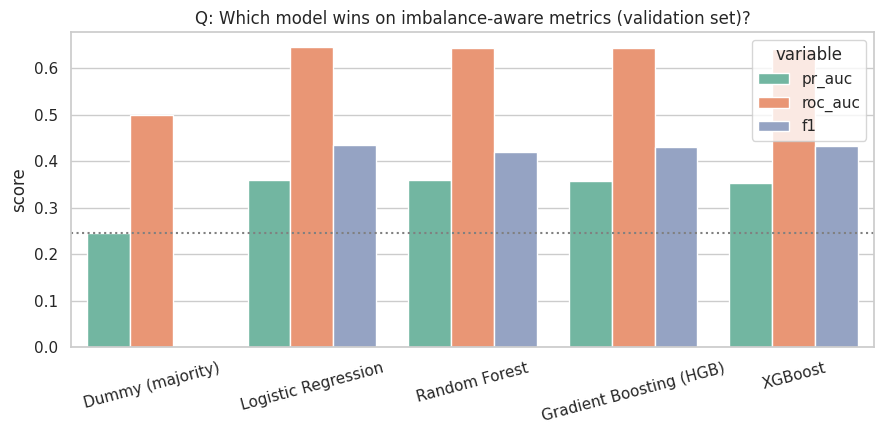

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = val_results_df[["pr_auc", "roc_auc", "f1"]].reset_index().melt(id_vars="index")
sns.barplot(data=plot_df, x="index", y="value", hue="variable", ax=ax, palette="Set2")
ax.set_title("Q: Which model wins on imbalance-aware metrics (validation set)?")
ax.set_xlabel("")
ax.set_ylabel("score")
ax.axhline(y_val.mean(), color="gray", linestyle=":", label="base rate")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/p3_01_model_comparison_val.png", bbox_inches="tight")
plt.show()

### ROC and Precision-Recall curves (validation set)

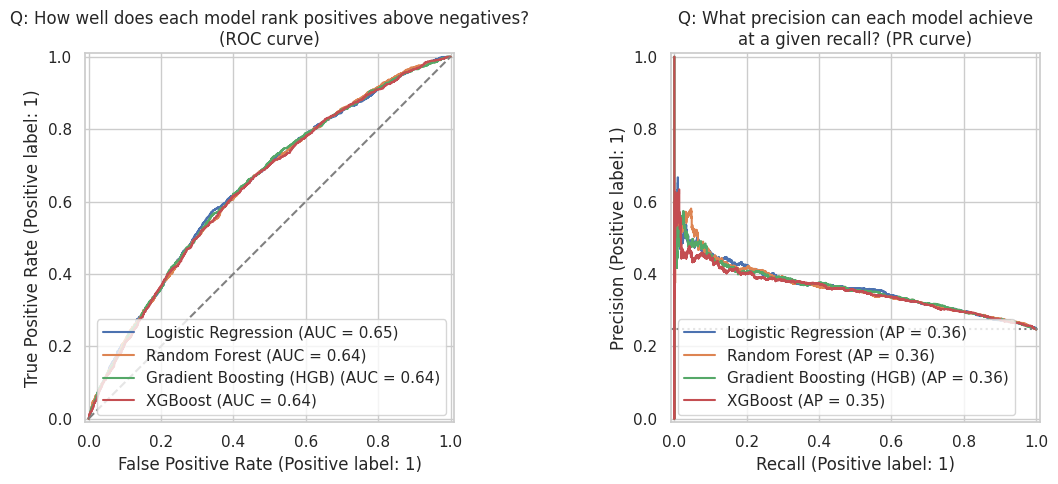

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, pipe in models.items():
    RocCurveDisplay.from_estimator(pipe, X_val, y_val, ax=axes[0], name=name)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("Q: How well does each model rank positives above negatives?\n(ROC curve)")

for name, pipe in models.items():
    PrecisionRecallDisplay.from_estimator(pipe, X_val, y_val, ax=axes[1], name=name)
axes[1].axhline(y_val.mean(), color="gray", linestyle=":", label="base rate")
axes[1].set_title("Q: What precision can each model achieve\nat a given recall? (PR curve)")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/p3_02_roc_pr_curves.png", bbox_inches="tight")
plt.show()

**Reading:** all four models cluster tightly (ROC-AUC ≈ 0.64, PR-AUC ≈
0.35–0.36) — a real, moderate lift over the dummy baseline (PR-AUC 0.25 =
base rate), but no model finds a dramatically stronger signal than the
others. This matches the EDA/interpretation finding below: there is
essentially **one dominant feature** (question length) plus many weak ones,
which caps how much tree-based non-linearity/interaction-modeling can add
over a well-regularized linear model.

### Confusion matrices (validation set, default 0.5 threshold)

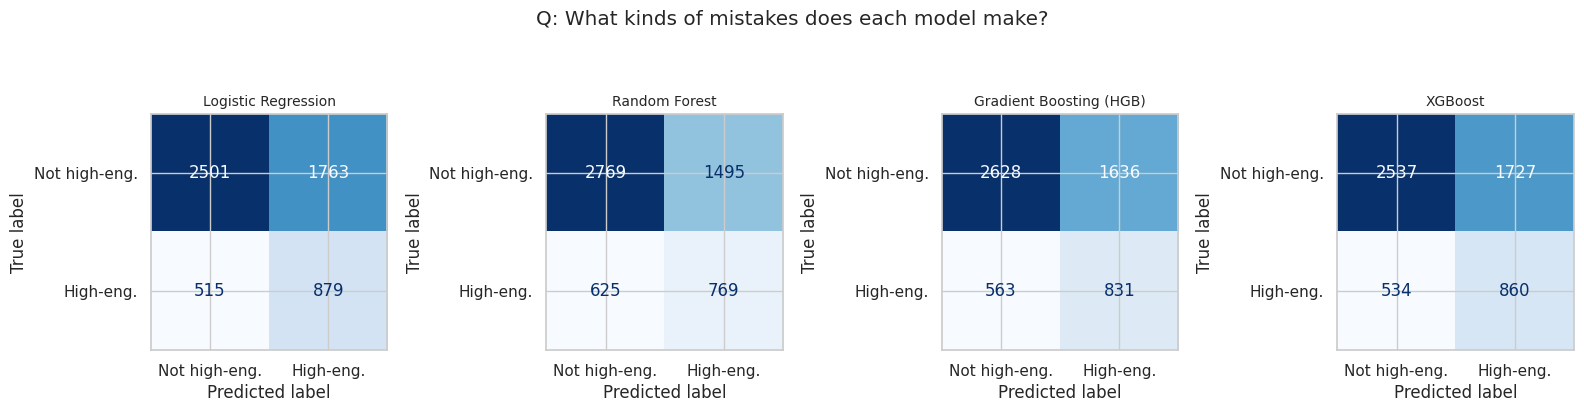

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, pipe) in zip(axes, models.items()):
    pred = (pipe.predict_proba(X_val)[:, 1] >= 0.5).astype(int)
    cm = confusion_matrix(y_val, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Not high-eng.", "High-eng."]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=10)
plt.suptitle("Q: What kinds of mistakes does each model make?", y=1.05)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/p3_03_confusion_matrices.png", bbox_inches="tight")
plt.show()

## 7. Best-Model Selection and Final Test-Set Evaluation

**Selection rule, decided *before* looking at test-set numbers:** rank by
validation PR-AUC first (the primary imbalance-aware metric), use ROC-AUC
and minority-class F1/recall as tie-breakers, and — per the brief's own
instruction to *"prioritize interpretability and business usefulness"* —
prefer the simpler model when performance is statistically indistinguishable.

In [13]:
best_name = val_results_df.drop(index="Dummy (majority)")["pr_auc"].idxmax()
print("Ranked by validation PR-AUC:")
print(val_results_df.drop(index="Dummy (majority)")[["pr_auc", "roc_auc", "f1"]].sort_values("pr_auc", ascending=False))
print(f"\nTop by PR-AUC: {best_name}")

Ranked by validation PR-AUC:
                         pr_auc  roc_auc      f1
Logistic Regression      0.3609   0.6452  0.4356
Random Forest            0.3608   0.6437  0.4204
Gradient Boosting (HGB)  0.3587   0.6445  0.4305
XGBoost                  0.3539   0.6409  0.4321

Top by PR-AUC: Logistic Regression


**Logistic Regression wins on validation PR-AUC and ROC-AUC**, with Random
Forest, Gradient Boosting, and XGBoost all within ~0.005–0.007 PR-AUC of it
— not a meaningful separation given the dataset size. Because Logistic
Regression (a) wins outright, and (b) is the most directly interpretable and
cheapest to deploy/monitor, it is selected as the primary model for the
interpretation and error-analysis sections below. The tree-based models are
kept in the final comparison as viable, near-equivalent alternatives — not
discarded, just not preferred without a performance reason to accept their
extra complexity.

In [14]:
test_results = {"Dummy (majority)": evaluate(dummy_pipe, X_test, y_test)}
for name, pipe in models.items():
    test_results[name] = evaluate(pipe, X_test, y_test)

test_results_df = pd.DataFrame(test_results).T.round(4)
print("FINAL TEST-SET RESULTS (touched only once, after model selection on validation):")
test_results_df

FINAL TEST-SET RESULTS (touched only once, after model selection on validation):


,roc_auc,pr_auc,f1,precision,recall
Dummy (majority),0.5000,0.2552,0.0000,0.0000,0.0000
Logistic Regression,0.6645,0.3954,0.4547,0.3490,0.6524
Random Forest,0.6603,0.3894,0.4427,0.3589,0.5776
Gradient Boosting (HGB),0.6603,0.3908,0.4457,0.3477,0.6205
XGBoost,0.6507,0.3769,0.4440,0.3380,0.6468


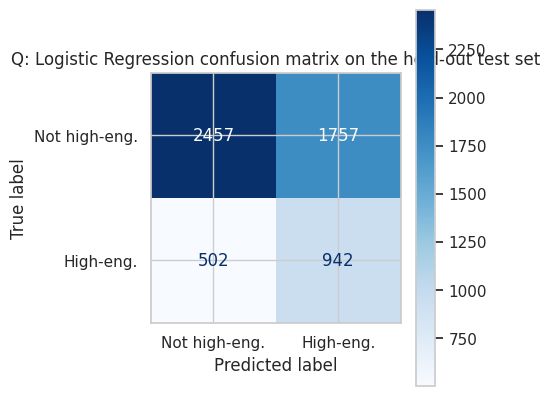

True Negatives : 2,457   False Positives: 1,757
False Negatives: 502   True Positives : 942

Test PR-AUC=0.395  (vs. base-rate floor 0.255)  ROC-AUC=0.664  Recall=0.652  Precision=0.349


In [15]:
best_pipe = models[best_name]
test_proba = best_pipe.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

cm = confusion_matrix(y_test, test_pred)
fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=["Not high-eng.", "High-eng."]).plot(ax=ax, cmap="Blues")
ax.set_title(f"Q: {best_name} confusion matrix on the held-out test set")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/p3_04_best_model_test_confusion.png", bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives : {tn:,}   False Positives: {fp:,}")
print(f"False Negatives: {fn:,}   True Positives : {tp:,}")
print(f"\nTest PR-AUC={test_results_df.loc[best_name,'pr_auc']:.3f}  "
      f"(vs. base-rate floor {y_test.mean():.3f})  "
      f"ROC-AUC={test_results_df.loc[best_name,'roc_auc']:.3f}  "
      f"Recall={test_results_df.loc[best_name,'recall']:.3f}  "
      f"Precision={test_results_df.loc[best_name,'precision']:.3f}")